In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

import joblib
import os

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


In [2]:
df = pd.read_csv("../data/raw/diabetic_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df = df.replace("?", np.nan)

missing_pct = df.isna().mean().mul(100).sort_values(ascending=False)
missing_pct[missing_pct > 0]


weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

In [4]:
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

print(df["readmitted_30"].value_counts())
print(df["readmitted_30"].value_counts(normalize=True).mul(100).round(2))

readmitted_30
0    90409
1    11357
Name: count, dtype: int64
readmitted_30
0    88.84
1    11.16
Name: proportion, dtype: float64


In [5]:
before = len(df)
df = df[df["gender"] != "Unknown/Invalid"].copy()
after = len(df)
print(f"Dropped {before - after} rows with gender == 'Unknown/Invalid'")
print("Remaining shape:", df.shape)


Dropped 3 rows with gender == 'Unknown/Invalid'
Remaining shape: (101763, 51)


In [6]:
RETAIN_FEATURES = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "admission_source_id",
    "medical_specialty",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "A1Cresult",
    "diag_1",   # provisional — engineered into diag_1_group below
]

ID_COLS = ["encounter_id", "patient_nbr"]  # patient_nbr used only for grouping
TARGET = "readmitted_30"

keep_cols = ID_COLS + RETAIN_FEATURES + [TARGET]
df_model = df[keep_cols].copy()
df_model.shape


(101763, 14)

In [7]:
def classify_icd9_diagnosis(code):
    """Group a primary-diagnosis ICD-9 code into clinical categories,
    following the scheme in Strack et al. (2014), Table 2."""
    if pd.isna(code):
        return "Missing"

    code = str(code)
    if code.startswith("V") or code.startswith("E"):
        return "Other"

    try:
        value = float(code)
    except ValueError:
        return "Other"

    if (390 <= value <= 459) or value == 785:
        return "Circulatory"
    if (460 <= value <= 519) or value == 786:
        return "Respiratory"
    if (520 <= value <= 579) or value == 787:
        return "Digestive"
    if 250 <= value < 251:
        return "Diabetes"
    if 800 <= value <= 999:
        return "Injury"
    if 710 <= value <= 739:
        return "Musculoskeletal"
    if (580 <= value <= 629) or value == 788:
        return "Genitourinary"
    if 140 <= value <= 239:
        return "Neoplasms"
    return "Other"


df_model["diag_1_group"] = df_model["diag_1"].apply(classify_icd9_diagnosis)
df_model = df_model.drop(columns=["diag_1"])

display(df_model["diag_1_group"].value_counts(dropna=False))

# Cast nominal ID-coded columns to string so they are one-hot encoded, not treated as numeric
for col in ["admission_type_id", "admission_source_id"]:
    df_model[col] = df_model[col].astype(str)


diag_1_group
Circulatory        30436
Other              18172
Respiratory        14423
Digestive           9475
Diabetes            8757
Injury              6972
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
Missing               21
Name: count, dtype: int64

In [8]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]
groups = df_model["patient_nbr"]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(sgkf.split(X, y, groups=groups))

train_df = df_model.iloc[train_idx].reset_index(drop=True)
test_df = df_model.iloc[test_idx].reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print()
print("Train class balance:")
print(train_df[TARGET].value_counts(normalize=True).mul(100).round(2))
print()
print("Test class balance:")
print(test_df[TARGET].value_counts(normalize=True).mul(100).round(2))


Train shape: (81526, 14)
Test shape: (20237, 14)

Train class balance:
readmitted_30
0    88.76
1    11.24
Name: proportion, dtype: float64

Test class balance:
readmitted_30
0    89.18
1    10.82
Name: proportion, dtype: float64


In [9]:
train_patients = set(train_df["patient_nbr"])
test_patients = set(test_df["patient_nbr"])
overlap = train_patients & test_patients

print("Patients in train:", len(train_patients))
print("Patients in test:", len(test_patients))
print("Overlapping patients:", len(overlap))

assert len(overlap) == 0, "Patient leakage detected between train and test sets!"
print("PASS: no patient appears in both train and test.")


Patients in train: 57175
Patients in test: 14340
Overlapping patients: 0
PASS: no patient appears in both train and test.


In [10]:
numeric_features = ["number_outpatient", "number_emergency", "number_inpatient"]

nominal_features = [
    "race", "gender", "admission_type_id", "admission_source_id",
    "medical_specialty", "A1Cresult", "diag_1_group",
]

ordinal_features = ["age"]
age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)",
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=[age_order])),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("nom", nominal_pipeline, nominal_features),
    ("ord", ordinal_pipeline, ordinal_features),
])

feature_cols = numeric_features + nominal_features + ordinal_features

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train = train_df[TARGET]
y_test = test_df[TARGET]

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)


Processed train shape: (81526, 120)
Processed test shape: (20237, 120)


In [11]:
train_clean = pd.DataFrame(X_train_processed, columns=feature_names)
train_clean[TARGET] = y_train.values

test_clean = pd.DataFrame(X_test_processed, columns=feature_names)
test_clean[TARGET] = y_test.values

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)

train_clean.to_csv("../data/processed/train_clean.csv", index=False)
test_clean.to_csv("../data/processed/test_clean.csv", index=False)

joblib.dump(preprocessor, "../models/preprocessor.joblib")

print("Saved:")
print(" - ../data/processed/train_clean.csv", train_clean.shape)
print(" - ../data/processed/test_clean.csv", test_clean.shape)
print(" - ../models/preprocessor.joblib")


Saved:
 - ../data/processed/train_clean.csv (81526, 121)
 - ../data/processed/test_clean.csv (20237, 121)
 - ../models/preprocessor.joblib


In [13]:


feature_df = pd.DataFrame(X_train_processed, columns=feature_names)

# 1. Near-zero-variance check (common after one-hot encoding rare categories)
variances = feature_df.var().sort_values()
near_zero_var = variances[variances < 0.01]

print(f"Total features: {feature_df.shape[1]}")
print(f"Near-zero-variance features (var < 0.01): {len(near_zero_var)}")
display(near_zero_var)

# 2. Highly correlated pairs (redundant information)
corr_matrix = feature_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.9
]

print(f"\nHighly correlated pairs (|r| > 0.9): {len(high_corr_pairs)}")
for col, row, val in sorted(high_corr_pairs, key=lambda x: -x[2])[:20]:
    print(f"  {row}  <->  {col}   r={val:.3f}")

Total features: 120
Near-zero-variance features (var < 0.01): 75


nom__admission_source_id_13                       0.000012
nom__medical_specialty_Neurophysiology            0.000012
nom__medical_specialty_Speech                     0.000012
nom__medical_specialty_Proctology                 0.000012
nom__medical_specialty_Psychiatry-Addictive       0.000012
                                                    ...   
nom__medical_specialty_ObstetricsandGynecology    0.006701
nom__medical_specialty_Urology                    0.006882
nom__medical_specialty_Pulmonology                0.008356
nom__medical_specialty_Psychiatry                 0.008380
nom__admission_source_id_5                        0.008525
Length: 75, dtype: float64


Highly correlated pairs (|r| > 0.9): 1
  nom__gender_Female  <->  nom__gender_Male   r=1.000


In [14]:
cols_to_drop = near_zero_var.index.tolist()
print(f"Dropping {len(cols_to_drop)} near-zero-variance columns:")
print(cols_to_drop)

train_clean_selected = train_clean.drop(columns=cols_to_drop)
test_clean_selected = test_clean.drop(columns=[c for c in cols_to_drop if c in test_clean.columns])

print("\nBefore:", train_clean.shape, "-> After:", train_clean_selected.shape)

# Re-save the feature-selected versions (overwrite or use new filenames — your call)
train_clean_selected.to_csv("../data/processed/train_clean_selected.csv", index=False)
test_clean_selected.to_csv("../data/processed/test_clean_selected.csv", index=False)
print("Saved feature-selected train/test CSVs.")

Dropping 75 near-zero-variance columns:
['nom__admission_source_id_13', 'nom__medical_specialty_Neurophysiology', 'nom__medical_specialty_Speech', 'nom__medical_specialty_Proctology', 'nom__medical_specialty_Psychiatry-Addictive', 'nom__medical_specialty_Pediatrics-InfectiousDiseases', 'nom__medical_specialty_Surgery-PlasticwithinHeadandNeck', 'nom__admission_source_id_11', 'nom__admission_source_id_25', 'nom__medical_specialty_Resident', 'nom__medical_specialty_Dentistry', 'nom__medical_specialty_Pediatrics-EmergencyMedicine', 'nom__medical_specialty_Pediatrics-AllergyandImmunology', 'nom__medical_specialty_Pediatrics-Hematology-Oncology', 'nom__medical_specialty_DCPTEAM', 'nom__medical_specialty_Psychiatry-Child/Adolescent', 'nom__medical_specialty_Surgery-Pediatric', 'nom__medical_specialty_AllergyandImmunology', 'nom__admission_type_id_4', 'nom__medical_specialty_Cardiology-Pediatric', 'nom__medical_specialty_Endocrinology-Metabolism', 'nom__admission_source_id_10', 'nom__admission

Original dimensionality: 45
Components needed for 90% variance: 15
Components needed for 95% variance: 22


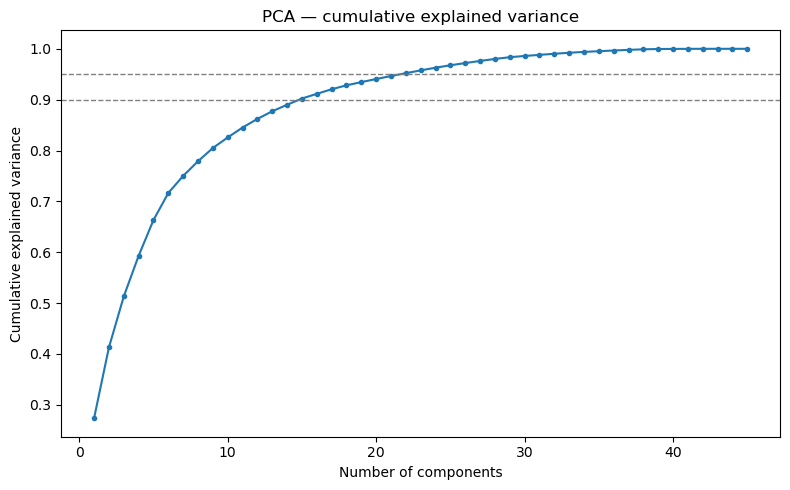

In [15]:
from sklearn.decomposition import PCA

# Use the feature-selected numeric matrix (excluding target)
X_train_for_pca = train_clean_selected.drop(columns=[TARGET])

pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_train_for_pca)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

n_for_90 = np.argmax(cumulative >= 0.90) + 1
n_for_95 = np.argmax(cumulative >= 0.95) + 1

print(f"Original dimensionality: {X_train_for_pca.shape[1]}")
print(f"Components needed for 90% variance: {n_for_90}")
print(f"Components needed for 95% variance: {n_for_95}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative) + 1), cumulative, marker=".")
plt.axhline(0.90, color="grey", linestyle="--", linewidth=1)
plt.axhline(0.95, color="grey", linestyle="--", linewidth=1)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA — cumulative explained variance")
plt.tight_layout()
plt.show()

In [16]:
# Quick check: do any of the near-zero-variance columns actually correlate with the target?
target_corr = feature_df.assign(**{TARGET: y_train.values}).corr()[TARGET].abs()
nzv_target_corr = target_corr[near_zero_var.index].sort_values(ascending=False)
print("Near-zero-variance features, ranked by correlation with target:")
display(nzv_target_corr.head(15))

Near-zero-variance features, ranked by correlation with target:


nom__medical_specialty_Hematology                           0.020789
nom__medical_specialty_ObstetricsandGynecology              0.017001
nom__medical_specialty_Surgery-Cardiovascular/Thoracic      0.013187
nom__medical_specialty_Pediatrics-Endocrinology             0.012280
nom__medical_specialty_Otolaryngology                       0.010107
nom__medical_specialty_Oncology                             0.009244
nom__diag_1_group_Missing                                   0.008305
nom__medical_specialty_Surgery-Neuro                        0.008275
nom__medical_specialty_Gynecology                           0.008271
nom__medical_specialty_PhysicalMedicineandRehabilitation    0.008249
nom__medical_specialty_Pediatrics                           0.008232
nom__medical_specialty_Neurology                            0.007612
nom__medical_specialty_Hematology/Oncology                  0.007118
nom__medical_specialty_Psychiatry                           0.007010
nom__medical_specialty_Endocrinolo